In [1]:
# train.csv 컬럼 설명
# msno      : 유저 고유 ID (2017년 2월 만료 코호트, PK)
# is_churn  : 타겟 변수. 현재 멤버십 만료 후 30일 이내 유효한 재구독이 없으면 1, 있으면 0
#
# 본 프로젝트는 train.csv만 사용한다.
# 입력 피처는 2017-01-31까지 관측된 거래·이용 기록으로 별도 생성하며,
# is_churn은 2월 만료 이후 30일의 미래 결과를 나타내는 정답 라벨로만 사용한다.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 스타일
# sns.set_style를 먼저 호출한 뒤 rcParams.update를 마지막에 적용해야
# seaborn이 font.family를 sans-serif로 되돌리는 것을 막을 수 있음
sns.set_style("whitegrid", {"grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7"})
plt.rcParams.update({
    "figure.dpi": 110,
    "font.family": "Malgun Gothic",
    "axes.unicode_minus": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b",
})

SERIES_1 = "#2a78d6"
SERIES_2 = "#eb6834"
pd.set_option("display.max_columns", None)

In [3]:
from pathlib import Path

RAW_DIR = Path("../data/raw").resolve()
train = pd.read_csv(RAW_DIR / "train.csv")

print("train shape:", train.shape)
print("\n자료형:")
print(train.dtypes)
display(train.head())

train shape: (992931, 2)

자료형:
msno          str
is_churn    int64
dtype: object


,msno,is_churn
0,waLDQMmcOu2jLDaV1ddDkgCrB/jl6sD66Xzs0Vqax1Y=,1
1,QA7uiXy8vIbUSPOkCf9RwQ3FsT8jVq2OxDr8zqa7bRQ=,1
2,fGwBva6hikQmTJzrbz/2Ezjm5Cth5jZUNvXigKK2AFA=,1
3,mT5V8rEpa+8wuqi6x0DoVd3H5icMKkE9Prt49UlmK+4=,1
4,XaPhtGLk/5UvvOYHcONTwsnH97P4eGECeq+BARGItRw=,1


In [4]:
print(f"전체 행 수: {len(train):,}")
print(f"고유 사용자 수: {train['msno'].nunique():,}")
print(f"msno 중복 수: {train['msno'].duplicated().sum():,}")
print(f"전체 행 중복 수: {train.duplicated().sum():,}")
print("\n결측치:")
print(train.isna().sum())
print("\nis_churn 고유값:", sorted(train['is_churn'].unique()))

전체 행 수: 992,931
고유 사용자 수: 992,931
msno 중복 수: 0
전체 행 중복 수: 0

결측치:
msno        0
is_churn    0
dtype: int64

is_churn 고유값: [np.int64(0), np.int64(1)]


In [5]:
target_summary = pd.DataFrame({
    "count": train["is_churn"].value_counts().sort_index(),
    "ratio": train["is_churn"].value_counts(normalize=True).sort_index(),
})
target_summary.index = ["잔존(0)", "이탈(1)"]
target_summary["ratio_pct"] = target_summary["ratio"] * 100
display(target_summary)

,count,ratio,ratio_pct
잔존(0),929460,0.936077,93.607713
이탈(1),63471,0.063923,6.392287


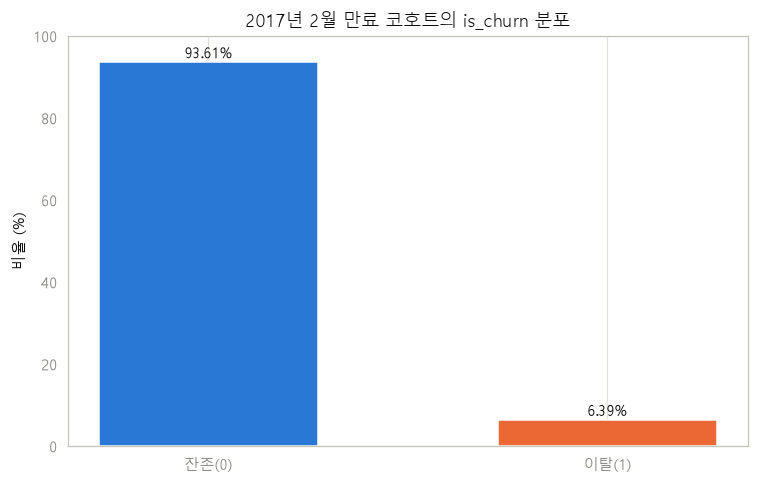

In [6]:
categories = ["잔존(0)", "이탈(1)"]
rates = train["is_churn"].value_counts(normalize=True).sort_index().values * 100
colors = [SERIES_1, SERIES_2]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(categories, rates, color=colors, width=0.55)
ax.set_ylabel("비율 (%)")
ax.set_title("2017년 2월 만료 코호트의 is_churn 분포")
ax.set_ylim(0, 100)
ax.grid(axis="y")
ax.set_axisbelow(True)

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, rate + 1, f"{rate:.2f}%", ha="center")

plt.tight_layout()
plt.show()

In [7]:
retained_count = (train["is_churn"] == 0).sum()
churn_count = (train["is_churn"] == 1).sum()
imbalance_ratio = retained_count / churn_count

print(f"잔존 고객 수: {retained_count:,}")
print(f"이탈 고객 수: {churn_count:,}")
print(f"이탈률: {churn_count / len(train) * 100:.2f}%")
print(f"클래스 비율(잔존:이탈): {imbalance_ratio:.2f}:1")

잔존 고객 수: 929,460
이탈 고객 수: 63,471
이탈률: 6.39%
클래스 비율(잔존:이탈): 14.64:1


In [8]:
majority_baseline_accuracy = (train["is_churn"] == 0).mean()

print(f"모든 사용자를 잔존으로 예측한 Accuracy: {majority_baseline_accuracy:.4f}")
print("하지만 이 기준선의 이탈 Recall은 0이므로 Accuracy만으로 모델을 평가하면 안 된다.")
print("모델 평가에서는 ROC-AUC, PR-AUC, Recall, F1을 함께 확인한다.")

모든 사용자를 잔존으로 예측한 Accuracy: 0.9361
하지만 이 기준선의 이탈 Recall은 0이므로 Accuracy만으로 모델을 평가하면 안 된다.
모델 평가에서는 ROC-AUC, PR-AUC, Recall, F1을 함께 확인한다.


In [9]:
# 분할 원칙 확인
print("분할 단위: msno(사용자)")
print("분할 방법: is_churn을 기준으로 stratified 70/15/15")
print("피처 관측 종료일: 2017-01-31")
print("타깃: 2월 만료 후 30일 이내 유효한 재구독 여부")

분할 단위: msno(사용자)
분할 방법: is_churn을 기준으로 stratified 70/15/15
피처 관측 종료일: 2017-01-31
타깃: 2월 만료 후 30일 이내 유효한 재구독 여부


In [10]:
# ------------------------------------------------------------------
# 분석 요약
# 1. train.csv는 2017년 2월 만료 사용자 992,931명의 단일 코호트다.
# 2. msno는 사용자별로 한 번만 등장하므로 사용자 단위 분할이 가능하다.
# 3. 이탈률은 약 6.4%로 클래스 불균형이 크다.
# 4. 분할 시 stratify를 적용하고 Accuracy 외에 PR-AUC, Recall, F1 등을 확인해야 한다.
# 5. 입력 피처는 반드시 2017-01-31까지 관측된 정보만 사용한다.
# ------------------------------------------------------------------
print("train.csv 단일 코호트 EDA 완료")

train.csv 단일 코호트 EDA 완료
